# 4.0 Modelado

Este notebook construye modelos de clustering para estudiar la pregunta principal del proyecto:

> **¿Qué caracteriza a los perfiles de resiliencia académica, es decir, estudiantes con bajo INSE que alcanzan percentiles sobresalientes en Saber Pro?**

La población de interés se define primero como los estudiantes ubicados en el 25% inferior del INSE. Los clusters se forman exclusivamente con características familiares y de trayectoria. El puntaje, el percentil, el INSE y la bandera de resiliencia no entran al modelo; se reservan para interpretar los resultados.

## 1. Librerías y carga de datos

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, MiniBatchKMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')

if Path('data/processed/Examen_Saber_Pro_Genericas_2024_limpio.csv').exists():
    project_root = Path.cwd()
else:
    project_root = Path.cwd().parent

input_path = project_root / 'data/processed/Examen_Saber_Pro_Genericas_2024_limpio.csv'
output_path = project_root / 'data/processed/saber_pro_2024_clusters_estudiantes.csv'
df = pd.read_csv(input_path, encoding='utf-8-sig', low_memory=False)
print(f'Dataset preparado: {df.shape[0]:,} filas x {df.shape[1]} columnas')

Dataset preparado: 259,703 filas x 95 columnas


## 2. Población y variables

Se conservan estudiantes con contexto socioeconómico y resultados globales válidos. Después se calcula el cuartil inferior del INSE. Esta decisión concentra el análisis en la población para la cual tiene sentido estudiar resiliencia académica.

In [2]:
ordinal_columns = ['fami_estratovivienda', 'fami_educacionmadre', 'fami_educacionpadre']
binary_columns = [
    'fami_tieneautomovil', 'fami_tienecomputador', 'fami_tienehornomicroogas',
    'fami_tieneinternet', 'fami_tienelavadora', 'fami_tienemotocicleta',
    'fami_tieneserviciotv'
]
categorical_columns = [
    'fami_ocupacionmadre', 'fami_ocupacionpadre',
    'fami_trabajolabormadre', 'fami_trabajolaborpadre',
    'estu_tituloobtenidobachiller', 'estu_actividadrefuerzogeneric',
    'estu_actividadrefuerzoareas', 'estu_cursoiesexterna',
    'estu_cursoiesapoyoexterno', 'estu_cursodocentesies',
    'estu_simulacrotipoicfes'
]
profiling_columns = [
    'estu_metodo_prgm', 'estu_nivel_prgm_academico', 'estu_nucleo_pregrado',
    'inst_caracter_academico', 'inst_origen', 'estu_prgm_departamento',
    'estu_prgm_academico', 'estu_snies_prgmacademico'
]

valid_mask = (
    df['estu_estudiante'].eq('ESTUDIANTE')
    & df['estado_contexto_socioeconomico'].eq('DISPONIBLE')
    & df['punt_global'].ne(-1)
    & df['percentil_global'].ne(-1)
)
df_valid = df.loc[valid_mask].copy()
inse_q25 = df_valid['estu_inse_individual'].quantile(0.25)
df_model = df_valid[df_valid['estu_inse_individual'] <= inse_q25].copy().reset_index(drop=True)
df_model['resiliencia_flag'] = df_model['percentil_global'] >= 90

print(f'Estudiantes válidos: {len(df_valid):,}')
print(f'Umbral de bajo INSE: {inse_q25:.2f}')
print(f'Estudiantes con bajo INSE: {len(df_model):,}')
print(f'Estudiantes resilientes: {df_model["resiliencia_flag"].sum():,}')

Estudiantes válidos: 247,770
Umbral de bajo INSE: 42.77
Estudiantes con bajo INSE: 61,943
Estudiantes resilientes: 2,208


## 3. Preparación de las variables del modelo

Las variables ordinales se convierten a números y se estandarizan. Se reconocen `Sin Estrato` y `Sin estrato` como la misma categoría. Los bienes del hogar se convierten a 0/1 y se incluyen de manera individual.

In [3]:
estrato_map = {'Sin Estrato': 0, 'Sin estrato': 0}
estrato_map.update({f'Estrato {number}': number for number in range(1, 7)})
education_order = [
    'Ninguno', 'Primaria incompleta', 'Primaria completa',
    'Secundaria (Bachillerato) incompleta', 'Secundaria (Bachillerato) completa',
    'Técnica o tecnológica incompleta', 'Técnica o tecnológica completa',
    'Educación profesional incompleta', 'Educación profesional completa', 'Postgrado'
]
education_map = {category: position for position, category in enumerate(education_order)}
education_map.update({'No sabe': 0, 'No Aplica': 0})

ordinal_data = pd.DataFrame({
    'estrato_ordinal': df_model['fami_estratovivienda'].map(estrato_map),
    'educacion_madre_ordinal': df_model['fami_educacionmadre'].map(education_map),
    'educacion_padre_ordinal': df_model['fami_educacionpadre'].map(education_map),
})
assert ordinal_data.notna().all().all(), 'Hay categorías ordinales sin transformar'
ordinal_scaler = StandardScaler()
ordinal_scaled = pd.DataFrame(
    ordinal_scaler.fit_transform(ordinal_data), columns=ordinal_data.columns
)
binary_data = df_model[binary_columns].replace({'Si': 1, 'No': 0}).astype('float32')
assert binary_data.notna().all().all(), 'Hay valores binarios sin transformar'
df_model['indice_bienes_hogar'] = binary_data.sum(axis=1)
display(df_model['indice_bienes_hogar'].describe().to_frame())

,indice_bienes_hogar
count,61943.000000
mean,2.910579
std,1.477358
min,0.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,7.000000


### 3.1 Agrupación de categorías poco frecuentes

Las categorías que representan menos del 0,5% de la población se agrupan como `OTRAS CATEGORÍAS`. Esto evita crear columnas casi vacías y perfiles definidos por muy pocos estudiantes. Las columnas one-hot permanecen como 0/1 para no aumentar artificialmente el peso de las categorías raras.

In [4]:
categorical_grouped = df_model[categorical_columns].astype(str).copy()
rare_categories = {}
rare_summary = []

for column in categorical_columns:
    frequencies = categorical_grouped[column].value_counts(normalize=True)
    rare_values = frequencies[frequencies < 0.005].index.tolist()
    rare_categories[column] = rare_values
    affected_rows = categorical_grouped[column].isin(rare_values).sum()
    categorical_grouped.loc[
        categorical_grouped[column].isin(rare_values), column
    ] = 'OTRAS CATEGORÍAS'
    rare_summary.append([column, len(rare_values), affected_rows])

rare_summary = pd.DataFrame(
    rare_summary, columns=['variable', 'categorias_agrupadas', 'registros_afectados']
)
display(rare_summary[rare_summary['categorias_agrupadas'] > 0])

one_hot_data = pd.get_dummies(
    categorical_grouped, prefix=categorical_columns, dtype='float32'
)
X = pd.concat(
    [ordinal_scaled, binary_data.reset_index(drop=True), one_hot_data.reset_index(drop=True)],
    axis=1
).astype('float32')
feature_names = X.columns.tolist()
print(f'Matriz del modelo: {X.shape[0]:,} filas x {X.shape[1]} variables')

,variable,categorias_agrupadas,registros_afectados
0,fami_ocupacionmadre,3,378
1,fami_ocupacionpadre,2,259
2,fami_trabajolabormadre,5,551
3,fami_trabajolaborpadre,6,957


Matriz del modelo: 61,943 filas x 94 variables


## 4. Selección de PCA y número de clusters para K-Means

Se prueban niveles de varianza PCA entre 70% y 90%, y valores de `k` entre 3 y 10. MiniBatchKMeans permite hacer la búsqueda rápidamente. Se descartan soluciones donde un cluster concentra más del 40% de la población y se elige la de mayor Silhouette.

In [5]:
kmeans_search = []
for retained_variance in [0.70, 0.80, 0.85, 0.90]:
    candidate_pca = PCA(n_components=retained_variance, random_state=RANDOM_STATE)
    X_candidate = candidate_pca.fit_transform(X).astype('float32')

    for k in range(3, 11):
        candidate = MiniBatchKMeans(
            n_clusters=k, n_init=10, batch_size=4096,
            max_iter=200, random_state=RANDOM_STATE
        )
        labels = candidate.fit_predict(X_candidate)
        kmeans_search.append({
            'varianza_pca': retained_variance,
            'componentes': X_candidate.shape[1],
            'k': k,
            'silhouette': silhouette_score(
                X_candidate, labels, sample_size=5_000, random_state=RANDOM_STATE
            ),
            'davies_bouldin': davies_bouldin_score(X_candidate, labels),
            'cluster_mayor_pct': pd.Series(labels).value_counts(normalize=True).max() * 100
        })

kmeans_search = pd.DataFrame(kmeans_search)
valid_solutions = kmeans_search[kmeans_search['cluster_mayor_pct'] <= 40]
best_kmeans = valid_solutions.sort_values(
    ['silhouette', 'davies_bouldin'], ascending=[False, True]
).iloc[0]
display(kmeans_search.sort_values('silhouette', ascending=False).head(10).round(3))
print('Configuración seleccionada:')
display(best_kmeans.to_frame().T.round(3))

,varianza_pca,componentes,k,silhouette,davies_bouldin,cluster_mayor_pct
1,0.70,10,4,0.170,1.718,34.669
8,0.80,15,3,0.164,1.952,55.480
2,0.70,10,5,0.158,1.902,30.032
9,0.80,15,4,0.144,2.016,48.662
7,0.70,10,10,0.135,2.052,18.230
3,0.70,10,6,0.132,2.330,28.898
5,0.70,10,8,0.130,1.991,23.063
4,0.70,10,7,0.117,2.079,27.317
6,0.70,10,9,0.115,2.164,19.318
16,0.85,19,3,0.114,2.322,38.335


Configuración seleccionada:


,varianza_pca,componentes,k,silhouette,davies_bouldin,cluster_mayor_pct
1,0.7,10.0,4.0,0.17,1.718,34.669


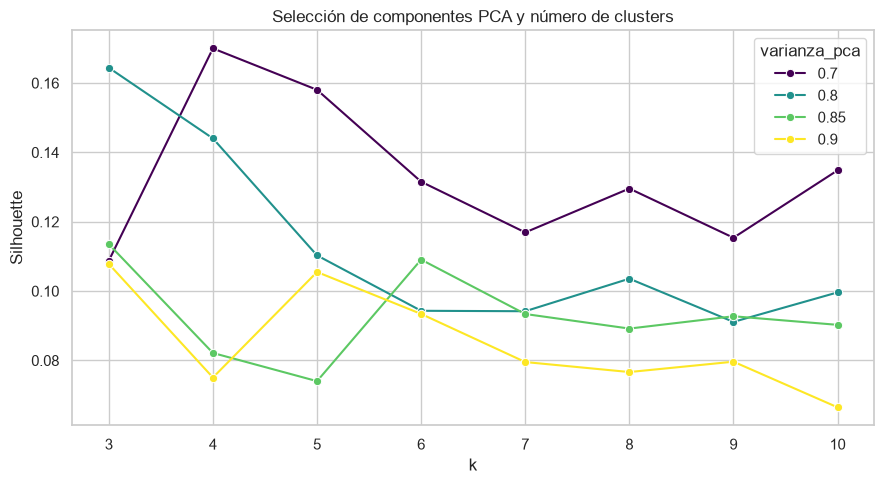

In [6]:
plt.figure(figsize=(9, 5))
sns.lineplot(data=kmeans_search, x='k', y='silhouette',
             hue='varianza_pca', marker='o', palette='viridis')
plt.title('Selección de componentes PCA y número de clusters')
plt.ylabel('Silhouette')
plt.tight_layout()
plt.show()

## 5. Entrenamiento final de K-Means

In [7]:
pca_kmeans = PCA(n_components=float(best_kmeans['varianza_pca']), random_state=RANDOM_STATE)
X_pca_kmeans = pca_kmeans.fit_transform(X).astype('float32')
k_final = int(best_kmeans['k'])
kmeans_final = KMeans(
    n_clusters=k_final, n_init=30, max_iter=500, random_state=RANDOM_STATE
)
df_model['cluster_kmeans'] = kmeans_final.fit_predict(X_pca_kmeans)
print(f'Componentes utilizadas: {X_pca_kmeans.shape[1]}')
print(f'Varianza conservada: {pca_kmeans.explained_variance_ratio_.sum() * 100:.2f}%')
display(df_model['cluster_kmeans'].value_counts().sort_index().to_frame('estudiantes'))

Componentes utilizadas: 10
Varianza conservada: 70.39%


,estudiantes
cluster_kmeans,
0,21541
1,19417
2,5272
3,15713


## 6. Selección y entrenamiento de DBSCAN

DBSCAN utiliza tres componentes PCA con `whiten=True` y una muestra reproducible de 30.000 estudiantes. Se prueban varios valores de `min_samples` y de `eps`. Se aceptan soluciones con 3 a 12 clusters, ruido entre 2% y 15% y un cluster dominante menor al 65%; entre ellas se elige la de mayor Silhouette.

In [8]:
pca_dbscan = PCA(n_components=3, whiten=True, random_state=RANDOM_STATE)
X_pca_dbscan = pca_dbscan.fit_transform(X).astype('float32')
rng = np.random.default_rng(RANDOM_STATE)
dbscan_index = rng.choice(len(X_pca_dbscan), size=30_000, replace=False)
X_dbscan_sample = X_pca_dbscan[dbscan_index]
dbscan_search = []

for min_samples in [30, 40, 50]:
    neighbors = NearestNeighbors(n_neighbors=min_samples, n_jobs=-1)
    distances = neighbors.fit(X_dbscan_sample).kneighbors(X_dbscan_sample)[0][:, -1]

    for distance_quantile in [0.90, 0.92, 0.94, 0.96]:
        eps = float(np.quantile(distances, distance_quantile))
        labels = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1).fit_predict(X_dbscan_sample)
        grouped = labels != -1
        cluster_count = len(set(labels)) - (1 if -1 in labels else 0)
        dbscan_search.append({
            'min_samples': min_samples, 'percentil_distancia': distance_quantile,
            'eps': eps, 'clusters': cluster_count,
            'ruido_pct': (~grouped).mean() * 100,
            'cluster_mayor_pct': pd.Series(labels[grouped]).value_counts(normalize=True).max() * 100,
            'silhouette': silhouette_score(
                X_dbscan_sample[grouped], labels[grouped], sample_size=5_000,
                random_state=RANDOM_STATE
            ) if cluster_count > 1 else np.nan,
            'davies_bouldin': davies_bouldin_score(
                X_dbscan_sample[grouped], labels[grouped]
            ) if cluster_count > 1 else np.nan
        })

dbscan_search = pd.DataFrame(dbscan_search)
valid_dbscan = dbscan_search[
    dbscan_search['clusters'].between(3, 12)
    & dbscan_search['ruido_pct'].between(2, 15)
    & (dbscan_search['cluster_mayor_pct'] < 65)
]
best_dbscan = valid_dbscan.sort_values(
    ['silhouette', 'davies_bouldin'], ascending=[False, True]
).iloc[0]
display(dbscan_search.round(3))
print('Configuración seleccionada:')
display(best_dbscan.to_frame().T.round(3))

,min_samples,percentil_distancia,eps,clusters,ruido_pct,cluster_mayor_pct,silhouette,davies_bouldin
0,30,0.90,0.138,13,6.670,52.495,0.382,0.556
1,30,0.92,0.160,15,5.050,51.971,0.362,0.579
2,30,0.94,0.189,13,3.420,51.163,0.371,0.618
3,30,0.96,0.234,12,2.180,50.872,0.325,0.759
4,40,0.90,0.156,12,6.547,52.796,0.383,0.603
5,40,0.92,0.181,14,4.873,51.882,0.342,0.589
6,40,0.94,0.215,11,3.300,51.462,0.373,0.670
7,40,0.96,0.268,8,2.213,50.897,0.387,0.893
8,50,0.90,0.172,6,6.960,53.035,0.416,0.709
9,50,0.92,0.201,11,5.077,52.042,0.376,0.633


Configuración seleccionada:


,min_samples,percentil_distancia,eps,clusters,ruido_pct,cluster_mayor_pct,silhouette,davies_bouldin
8,50.0,0.9,0.172,6.0,6.96,53.035,0.416,0.709


In [9]:
dbscan_final = DBSCAN(
    eps=float(best_dbscan['eps']),
    min_samples=int(best_dbscan['min_samples']),
    n_jobs=-1
)
dbscan_labels = dbscan_final.fit_predict(X_dbscan_sample)
df_model['cluster_dbscan'] = np.nan
df_model.loc[dbscan_index, 'cluster_dbscan'] = dbscan_labels
print(f'Clusters DBSCAN: {int(best_dbscan["clusters"])}')
print(f'Ruido: {best_dbscan["ruido_pct"]:.2f}%')
display(pd.Series(dbscan_labels).value_counts().sort_index().to_frame('estudiantes'))

Clusters DBSCAN: 6
Ruido: 6.96%


,estudiantes
-1,2088
0,9955
1,14803
2,1796
3,96
4,1161
5,101


## 7. Guardado de los nuevos resultados

In [10]:
kmeans_pca_columns = [f'pca_{number + 1}' for number in range(X_pca_kmeans.shape[1])]
dbscan_pca_columns = [f'dbscan_pca_{number + 1}' for number in range(X_pca_dbscan.shape[1])]
df_kmeans_pca = pd.DataFrame(X_pca_kmeans, columns=kmeans_pca_columns)
df_kmeans_pca['pca_plot_1'] = X_pca_kmeans[:, 0]
df_kmeans_pca['pca_plot_2'] = X_pca_kmeans[:, 1]
df_dbscan_pca = pd.DataFrame(X_pca_dbscan, columns=dbscan_pca_columns)

export_columns = (
    ['estu_consecutivo', 'cluster_kmeans', 'cluster_dbscan', 'resiliencia_flag',
     'punt_global', 'percentil_global', 'estu_inse_individual', 'indice_bienes_hogar']
    + ordinal_columns + binary_columns + categorical_columns + profiling_columns
)
df_export = pd.concat(
    [df_model[export_columns].reset_index(drop=True), df_kmeans_pca, df_dbscan_pca],
    axis=1
)
assert df_export['cluster_kmeans'].notna().all()
assert df_export['cluster_dbscan'].notna().sum() == 30_000
output_path.parent.mkdir(parents=True, exist_ok=True)
df_export.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f'Archivo guardado: {output_path.resolve()}')
print(f'Dimensiones: {df_export.shape[0]:,} filas x {df_export.shape[1]} columnas')

Archivo guardado: /Users/fermin/Documents/GitHub/colombia-higher-ed-assessment-analysis/data/processed/saber_pro_2024_clusters_estudiantes.csv
Dimensiones: 61,943 filas x 52 columnas


## 8. Resultado del modelado

- La población modelada corresponde exclusivamente a estudiantes con bajo INSE.
- Los clusters se construyen con contexto familiar y trayectoria, sin utilizar el resultado académico.
- K-Means se entrena con la combinación de PCA y `k` seleccionada mediante métricas y control de tamaño.
- DBSCAN se entrena sobre 30.000 registros y tres componentes apropiadas para estudiar densidad.
- El archivo exportado contiene las etiquetas y componentes necesarias para la fase de evaluación.